In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  


In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from region import Region
from functions import Functions
fns = Functions()

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
from cartopy.feature import LAND

In [4]:
elevation_ = GEBCO(coarsen_factor=4).ds.elevation

In [5]:
sla_ = SLA(deg=0.25).da
winds_ = xr.open_dataset('../data/ef25db236e60a21a34ee2e0b4631d366.nc').sortby('latitude').rename({'valid_time':'time'})
sam = Index(type='SAM').da.sel(time=slice(sla_.time[0],sla_.time[-1]))
dotds = DOT().ds.rename({'ug':'u10','vg':'v10'})
sice_ = xr.open_dataset('../data/NSIDC/sice_processed.nc').__xarray_dataarray_variable__


In [6]:
extent_ac = [138,152,-68,-63]
extent_ea = [60,160,-70,-60]

elevation_ea = elevation_.sel(latitude = slice(extent_ea[2], extent_ea[3]), longitude = slice(extent_ea[0],extent_ea[1]))
elevation_ac = elevation_.sel(latitude = slice(extent_ac[2], extent_ac[3]), longitude = slice(extent_ac[0],extent_ac[1]))

In [7]:
region_ac = Region('AC',extent_ac,elevation=elevation_ac)
region_ac_shelf = Region('ACS',extent_ac,elevation=elevation_ac,min_elevation=-1000)
region_ea = Region('EA',extent_ea)

winds_ea = region_ea.crop_da(winds_)

sla = region_ac.crop_da(sla_)
sla_shelf = region_ac_shelf.crop_da(sla_)
winds = region_ac.crop_da(winds_)
dot =region_ac.crop_da(dotds)
sice = region_ac.crop_da(sice_)
sic_shelf = region_ac_shelf.crop_da(sice_)

# filter dodgy sla signal
lonboo = sla.longitude < 147
latboo = sla.latitude > -66.6
sla = sla.where(lonboo | latboo,drop=True)

In [8]:
u,v = fns.get_geostrophic_currents(sla)
geos = xr.Dataset({'u10':u,'v10':v})

In [9]:
sa_sla = fns.seasonal_anomaly(sla.interpolate_na(dim='time'))
sa_geos = fns.seasonal_anomaly(geos.interpolate_na(dim='time'))
sa_winds = fns.seasonal_anomaly(winds.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
sa_sic = fns.seasonal_anomaly(sice.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
sa_sics = fns.seasonal_anomaly(sic_shelf.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))

In [10]:
t2014 = lambda ds: ds.sel(time=slice(pd.Timestamp(2014,1,1),pd.Timestamp(2014,12,1))).mean('time')

In [11]:
sla_winds = sla_.interp_like(winds_)

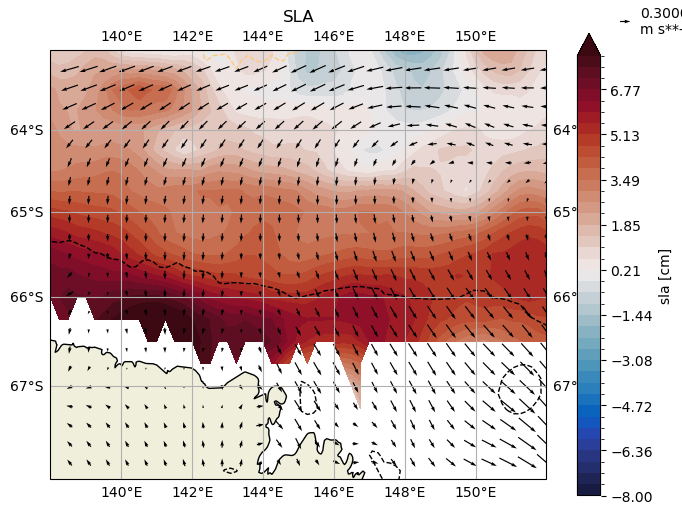

In [12]:
fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.Mercator()})
fns.plotc(ax,t2014(sa_sla),'SLA',extent_ac,vmin=-8,vmax=8,vector=t2014(sa_winds))


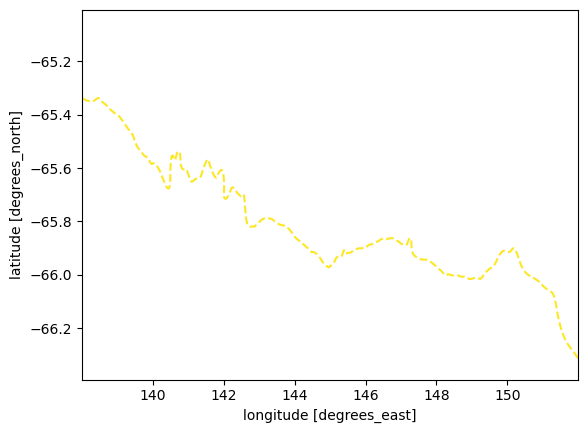

In [13]:
cc=elevation_ac.sel(latitude=slice(-66.4,-65)).plot.contour(levels=[-1000])

In [14]:
lats = xr.DataArray(cc.allsegs[0][0].T[1],coords={'longitude':cc.allsegs[0][0].T[0]})
asclats = lats.sortby('longitude').interp(longitude=geos.longitude,kwargs={'fill_value':'extrapolate'})

In [15]:
# isolate asc on slope = -1000
geos['asc_latitude'] = xr.DataArray(asclats,coords={'longitude':geos.longitude})
geos['asc'] = geos.u10.sel(latitude=geos.asc_latitude,method='nearest')

In [16]:
R = 6371000
lat_radians = np.deg2rad(geos.asc_latitude)

dx = R * np.cos(lat_radians[:-1]) * np.deg2rad(np.diff(geos.longitude))
dy = R * np.deg2rad(np.diff(geos.asc_latitude))

delta = np.stack([dx,dy],axis=1)
t_hat = delta / np.linalg.norm(delta, axis=1)[:, None]

In [17]:
# Interpolate u and v onto path points for all times
u_path = geos.u10.interp(latitude=geos.asc_latitude, longitude=geos.longitude)
v_path = geos.v10.interp(latitude=geos.asc_latitude, longitude=geos.longitude)
# We project using the unit vector of each segment; use the starting point of each segment
u_seg = u_path[:, :-1]  # drop last point (segments)
v_seg = v_path[:-1, :]

In [18]:
dathatx = xr.DataArray(t_hat[:,0],coords={'longitude':u_seg.longitude})
dathaty = xr.DataArray(t_hat[:,1],coords={'longitude':u_seg.longitude})
v_along = u_seg * dathatx + v_seg * dathaty # shape: (time, segments)

In [19]:
# strength of easterlies and westerlies
eastl = -winds.u10.sel(latitude=slice(-68,-65)).mean(['latitude','longitude'])
westl = winds.u10.sel(latitude=slice(-64,-55)).mean(['latitude','longitude'])
# strength of ASC/ACC
#asc = geos.u10.sel(latitude=slice(-66.25,-65.5)).mean(['latitude','longitude'])
acc = geos.u10.sel(latitude=slice(-65,-63)).mean(['latitude','longitude'])
# coastal ssh
cssh = sla_shelf.mean(['latitude','longitude'])
csic = sic_shelf.mean(['latitude','longitude'])

In [20]:
# new asc
asc = -v_along.mean('longitude')

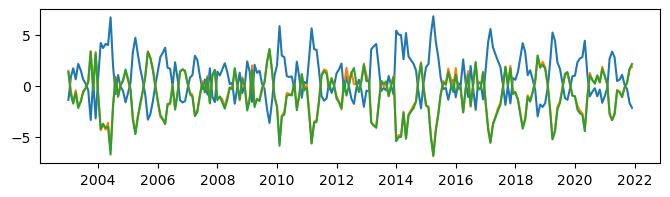

In [21]:
fig,ax = plt.subplots(figsize=(8,2))
ax.plot(geos.time,asc)
ax.plot(geos.time,geos.asc.mean('longitude'))
ax.plot(geos.time,v_along.mean('longitude'))

In [48]:
asc.to_netcdf('asc_index.nc')
acc.to_netcdf('acc_index.nc')
cssh.to_netcdf('ssh_index.nc')
sam.to_netcdf('sam_index.nc')
csic.to_netcdf('sic_index.nc')


In [41]:
colors = plt.cm.tab20b(np.linspace(0, 0.75, 4))


Rendering..


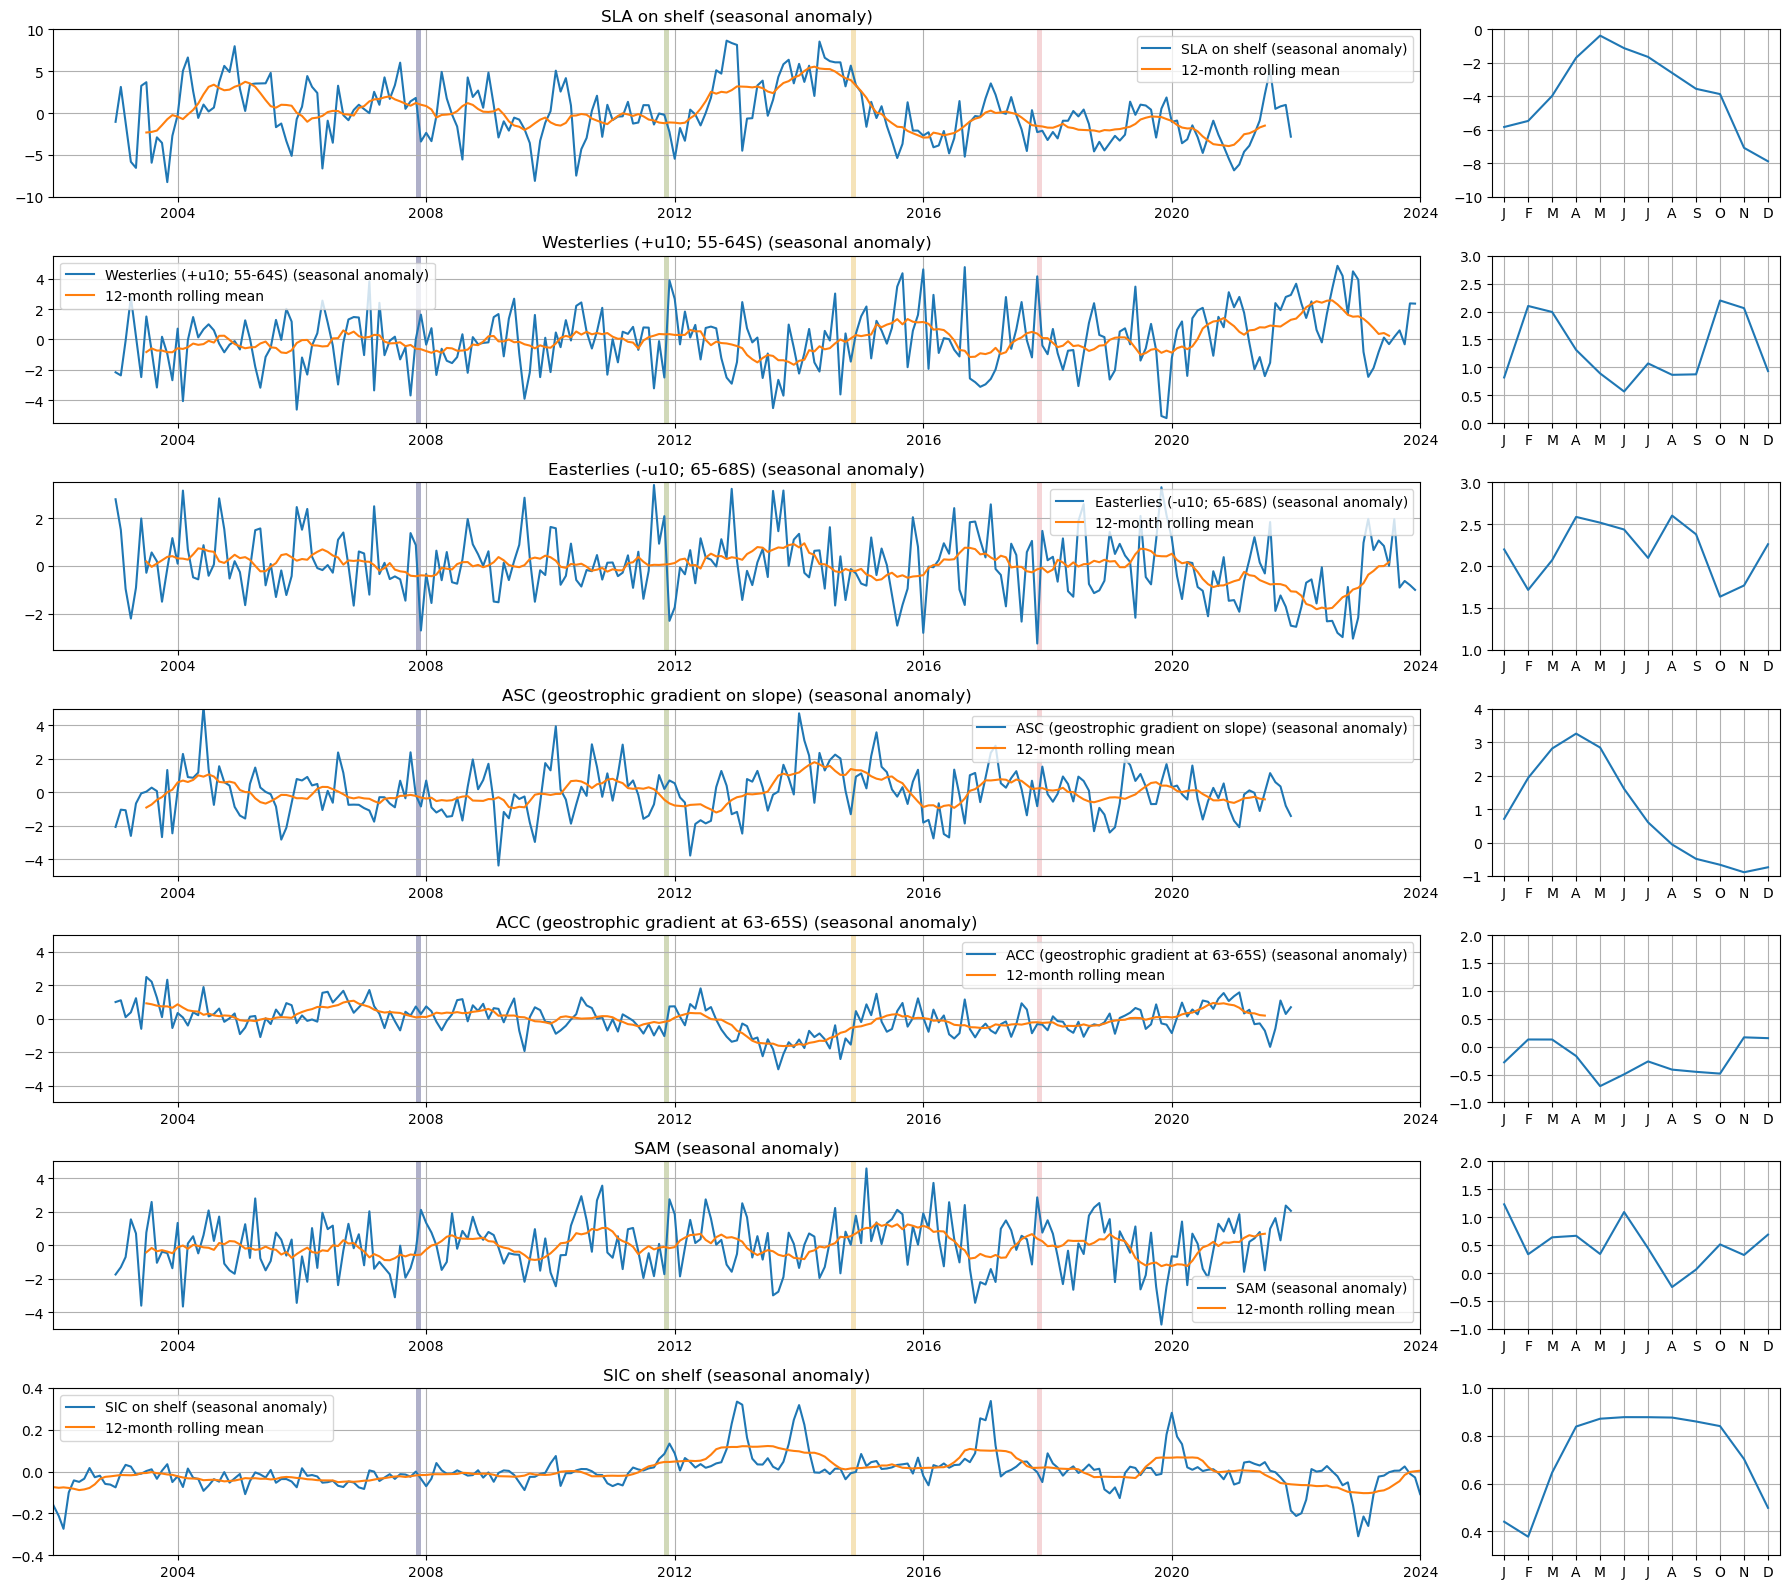

In [44]:
fig = plt.figure(figsize=(18,16))
axs=[]

gs = fig.add_gridspec(7,5)

def add_row(n,var,varname,ylim=[-16,16],ylim_cmt=[-7,7],anom=False):

    axs.append(fig.add_subplot(gs[n,0:4]))
    axs.append(fig.add_subplot(gs[n,4:6]))

    if 'latitude' in var.dims:
        da = var.mean(['latitude','longitude'])
    else:
        da = var
        
    cmt = da.groupby('time.month').mean()

    ax = axs[(n*2)]

    if anom:
        da = da.groupby('time.month') - cmt
        varname = varname + ' (seasonal anomaly)'

    ax.plot(da.time,da,label=varname)
    ax.plot(da.time,da.rolling(time=12,center=True).mean(),label='12-month rolling mean')

    ax.set_title(varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2002,1,1),pd.Timestamp(2024,1,1)])
    ax.grid()

    for y,c in zip([2007,2011,2014,2017],colors):
        t1a = pd.Timestamp(y,10,1)
        t1b = pd.Timestamp(y+1,1,1)
        tboo = (da.time > t1a) & (da.time < t1b)
        
        ax.fill_between(da.time, ylim[0],ylim[1], where=tboo, alpha=0.4, facecolor=c,label='spring '+str(y))

    ax = axs[(n*2)+1]

    ax.plot(cmt.month,cmt)
    ax.set_ylim(ylim_cmt)
    ax.grid()
    ax.set_xticks(cmt.month,labels=['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])



add_row(0,cssh,'SLA on shelf',anom=True,ylim=[-10,10],ylim_cmt=[-10,0])
add_row(1,westl,'Westerlies (+u10; 55-64S)',anom=True,ylim=[-5.5,5.5],ylim_cmt=[0,3])
add_row(2,eastl,'Easterlies (-u10; 65-68S)',anom=True,ylim=[-3.5,3.5],ylim_cmt=[1,3])
add_row(3,asc,'ASC (geostrophic gradient on slope)',anom=True,ylim=[-5,5],ylim_cmt=[-1,4])
add_row(4,acc,'ACC (geostrophic gradient at 63-65S)',anom=True,ylim=[-5,5],ylim_cmt=[-1,2])
add_row(5,sam,'SAM',anom=True,ylim=[-5,5],ylim_cmt=[-1,2])
add_row(6,sic_shelf,'SIC on shelf',anom=True,ylim=[-0.4,0.4],ylim_cmt=[0.3,1])




plt.tight_layout()
print('Rendering..')


In [25]:
from scipy.stats import pearsonr

vars = [cssh,eastl,westl,acc,asc,sam,csic]
cmat = np.empty((len(vars),len(vars)))
pmat = np.empty((len(vars),len(vars)))

# vars = []

# for v in vars_:
#     cmt = v.groupby('time.month').mean()
#     var = (v-cmt).rolling({'time':12},center=True).mean()
#     vars.append(var)
ts = cssh.time[0]

for i,v in enumerate(vars):
    for j,w in enumerate(vars):
        vw, wv = xr.align(v,w)
        cmat[i][j] = xr.corr(vw,wv).item()
        pmat[i][j] = pearsonr(vw, wv)[1]

In [26]:
matt = pd.DataFrame(cmat,columns=['SLA','E-LIES','W-LIES','ACC','ASC','SAM','SIC'],index=['SLA','E-LIES','W-LIES','ACC','ASC','SAM','SIC'])

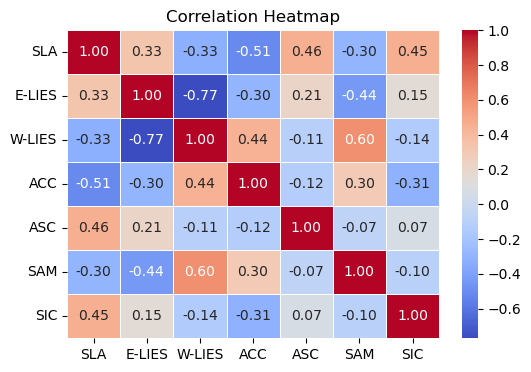

In [27]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(matt, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [28]:
#repeat with extra plots
sose140 = xr.open_dataset('sose_shelf_140.nc')
sose145 = xr.open_dataset('sose_shelf_145.nc')

In [29]:
vars = [cssh,asc,sam,csic,sose145.THETA.mean(['Z','YC']),sose145.SALT.mean(['Z','YC'])]
cmat = np.empty((len(vars),len(vars)))
pmat = np.empty((len(vars),len(vars)))

# vars = []

# for v in vars_:
#     cmt = v.groupby('time.month').mean()
#     var = (v-cmt).rolling({'time':12},center=True).mean()
#     vars.append(var)
ts = cssh.time[0]

for i,v in enumerate(vars):
    for j,w in enumerate(vars):
        vw, wv = xr.align(v,w)
        cmat[i][j] = xr.corr(vw,wv).item()
        pmat[i][j] = pearsonr(vw, wv)[1]

In [31]:
matt = pd.DataFrame(cmat,columns=['SLA','ASC','SAM','SIC','SOSE140 THETA','SOSE140 SALT'],index=['SLA','ASC','SAM','SIC','SOSE140 THETA','SOSE140 SALT'])

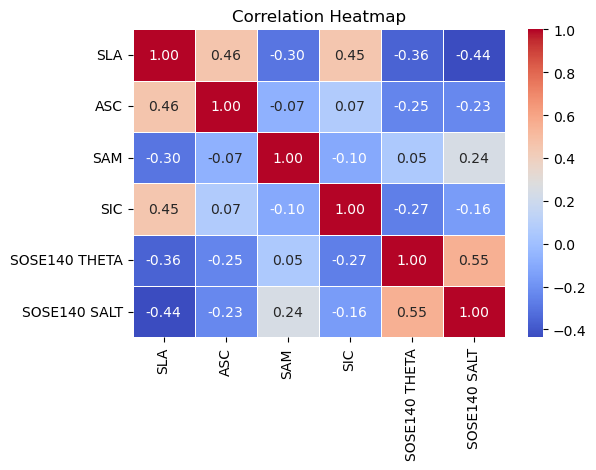

In [32]:

plt.figure(figsize=(6,4))
sns.heatmap(matt, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#repeat with extra plots
glorys = xr.open_dataset('glorys_shelf_140.nc')

In [35]:
mglorys = glorys.mean(['latitude','longitude','depth'])

In [36]:
vars = [cssh,asc,csic,sose145.THETA.mean(['Z','YC']),sose145.SALT.mean(['Z','YC']),mglorys.thetao,mglorys.so]
cmat = np.empty((len(vars),len(vars)))
pmat = np.empty((len(vars),len(vars)))

# vars = []

# for v in vars_:
#     cmt = v.groupby('time.month').mean()
#     var = (v-cmt).rolling({'time':12},center=True).mean()
#     vars.append(var)
ts = cssh.time[0]

for i,v in enumerate(vars):
    for j,w in enumerate(vars):
        vw, wv = xr.align(v,w)
        cmat[i][j] = xr.corr(vw,wv).item()
        pmat[i][j] = pearsonr(vw, wv)[1]

In [38]:
matt = pd.DataFrame(cmat,columns=['SLA','ASC','SIC','SOSE T','SOSE S','GLORYS T','GLORYS S'],index=['SLA','ASC','SIC','SOSE T','SOSE S','GLORYS T','GLORYS S'])

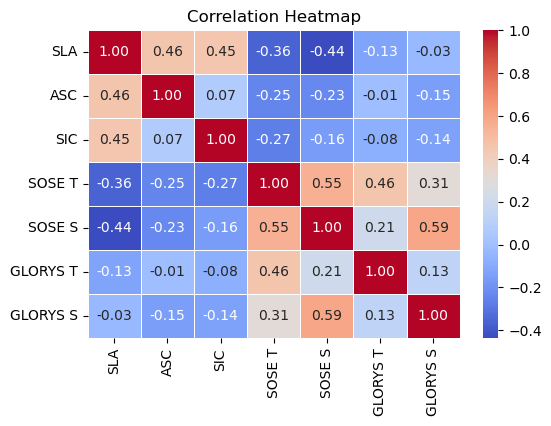

In [40]:

plt.figure(figsize=(6,4))
sns.heatmap(matt, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [51]:

var1 = sose145.THETA.mean(['Z','YC'])
vars = [cssh,westl,eastl,asc,sam,acc,csic]
lags = np.arange(-12,13,1)
cmat = np.empty((len(vars),len(lags)))
pmat = np.empty((len(vars),len(lags)))


ts = cssh.time[0]

for i,v in enumerate(vars):
    for j,w in enumerate(lags):
        vw, wv = xr.align(v,var1.shift({'time':w}))
        cmat[i][j] = xr.corr(vw,wv).item()
        pmat[i][j] = pearsonr(vw, wv)[1]

In [52]:
matt = pd.DataFrame(cmat.T,columns=['SLA','W-LIES','E-LIES','ASC','SAM','ACC','SIC'],index=[str(n) for n in lags])

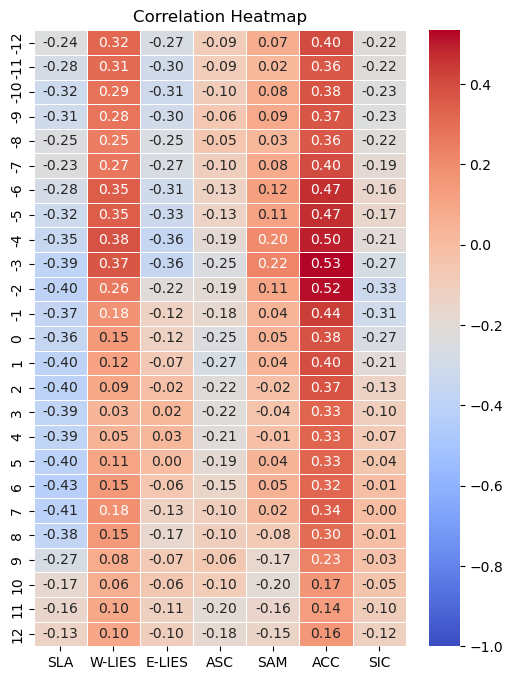

In [53]:
plt.figure(figsize=(6,8))
sns.heatmap(matt, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1)
plt.title("Correlation Heatmap")
plt.show()